# Task 2 – Classification: Predict Booking Cancellations

## 1. Business Understanding

## 2. Data Preparation

## 3. Model 1 - Logistic Regression

## 4. Model 2 - Decision Tree

## 5. Model 3 - Random Forest

## 6. Evaluation and Reporting

## 7. Business Recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

In [2]:
df = pd.read_csv("hotel_bookings_cleaned.csv")
print(df.shape)

(119390, 36)


In [3]:
# Remove any remaining missing values

df = df.dropna()

print(df.isnull().sum().sum())
print(df.shape)

0
(119390, 36)


## 1. Business Understanding

The objective of this classification task is to predic whether a hotel booking will be canceled. Accurate cancelation prediction helps hotels improve resource allocation, occupancy planning, and revenue management.

In [4]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


Train-Test Split

In [5]:
X = df.drop("is_canceled", axis=1)

y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (95512, 35)
Testing Set: (23878, 35)


In [6]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


## 2. Model 1 - Logistic Regression

In [7]:
log_model = LogisticRegression(
    max_iter=10000,
    solver="liblinear"
)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.7968841611525254
Precision: 0.812528439253754
Recall: 0.5971463604949281
F1 Score: 0.6883834489848368


### Logistic Regression Result

The Logistic Regression model achieved an accuracy of 79.69%, precision of 81.25%, recall of 59.71%, and F1 score of 68.84%. This shows that the model performed reasonably well, but its recall was lower compared to the tree-based models, meaning it missed more cancelled bookings.

## 3. Model 2 - Decision Tree

### Hyperparameters

- max_depth = 10
- random_state = 42

The maximum depth limits tree complexity and reduces overfitting.

In [8]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.8421978390149929
Precision: 0.8244170096021948
Recall: 0.7369301081261844
F1 Score: 0.7782224838140083


### Decision Tree Results

The Decision Tree Model got an accuracy of 84.22%, outperforming the Logistic Regression. The model produced a precision of 82.44%, recall of 73.69% and a F1-score of 77.82%. The imprved performance suggests that the Decision Tree was better able to capture non-linear relationships with in the hotel booking dataset and identify the booking cancellations more effectively.

## 4. Model 3 - Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8976463690426334
Precision: 0.8975514679010842
Recall: 0.8213131200535058
F1 Score: 0.8577415599534343


In [10]:
from sklearn.metrics import roc_auc_score

log_reg_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print("Logistic Regression ROC-AUC:", log_reg_auc)
print("Decision Tree ROC-AUC:", dt_auc)
print("Random Forest ROC-AUC:", rf_auc)

Logistic Regression ROC-AUC: 0.8691490593218101
Decision Tree ROC-AUC: 0.9195825510428619
Random Forest ROC-AUC: 0.9604848840352639


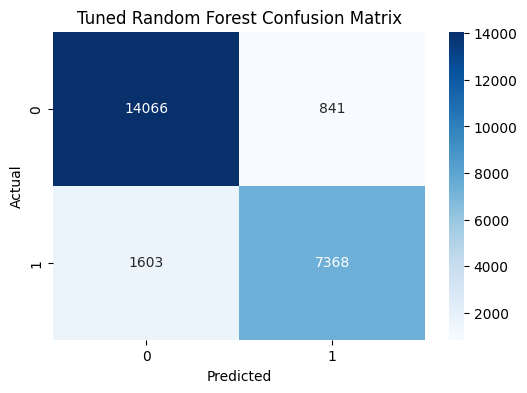

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix was used to evaluate the performance of the Random Forest Classification model.

The model correctly identified 14,066 non-cancelled bookings and 7,368 cancelled bookings. A relatively small number of bookings were misclassified, indicating strong predictive performance.

This result demonstrates that the Random Forest model can effectively identify high-risk bookings, helping hotel management reduce revenue loss through better cancellation forecasting and overbooking strategies.

## Hyperparameter Fine-Tuning

GridSearchCV was used to identify the best Random Forest hyperparameters. Different values of n_estimators and max_depth were evaluated using cross-validation. The best-performing parameter combination was selected for the final model.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 150}
Best Cross Validation Accuracy: 0.8860143102862298


In [13]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

best_rf_auc = roc_auc_score(
    y_test,
    best_rf.predict_proba(X_test)[:, 1]
)

print("ROC-AUC:", best_rf_auc)

Accuracy: 0.8981908032498535
Precision: 0.8984889105532538
Recall: 0.8218704715193401
F1 Score: 0.8584735401991035
ROC-AUC: 0.9611014328295917


## 5. Evaluation and Reporting

In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.7969,
        0.8422,
        0.8982
    ],
    "Precision": [
        0.8125,
        0.8244,
        0.8985
    ],
    "Recall": [
        0.5971,
        0.7369,
        0.8219
    ],
    "F1 Score": [
        0.6884,
        0.7782,
        0.8585
    ],
    "ROC-AUC": [
        log_reg_auc,
        dt_auc,
        best_rf_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7969,0.8125,0.5971,0.6884,0.869149
1,Decision Tree,0.8422,0.8244,0.7369,0.7782,0.919583
2,Tuned Random Forest,0.8982,0.8985,0.8219,0.8585,0.961101


### Model Comparison

Tuned Random Forest achieved the highest Accuracy (0.8982), Precision (0.8985), Recall (0.8219), F1 Score (0.8585), and ROC-AUC (0.9611), making it the best-performing classification model for predicting booking cancellations.

Compared to Logistic Regression and Decision Tree, the Tuned Random Forest model demonstrated superior predictive performance across all evaluation metrics. This indicates that the model is more effective at identifying both cancelled and non-cancelled bookings.

For hotel management, the model can be used to identify high-risk bookings early, support overbooking strategies, improve resource planning, and reduce revenue losses caused by unexpected cancellations.

## Hyperparameter Explanations

### Logistic Regression
- max_iter = 10000
- solver = liblinear

The number of iterations was increased and the liblinear solver was used to improve convergence during model training.

### Decision Tree
- max_depth = 10

The maximum depth was limited to reduce overfitting and improve model generalization.

### Random Forest
- n_estimators = 150
- max_depth = None
- random_state = 42

GridSearchCV identified these as the best-performing hyperparameters. The model uses 150 decision trees, while max_depth = None allows trees to grow fully. The random_state parameter ensures reproducible results.

## 6. Business Recommendations

The tuned Random Forest model can be used by hotel management to identify bookings with a high risk of cancellation. Early detection of potential cancellations can support better overbooking strategies, improve room allocation, and reduce revenue losses. The model achieved the highest classification performance among all evaluated algorithms, making it the most suitable choice for cancellation prediction within the hotel booking environment.

### Hyperparameter Fine-Tuning

Hyperparameter fine-tuning was performed using GridSearchCV on the Random Forest model. Different combinations of n_estimators and max_depth were evaluated using cross-validation. The best-performing parameters were identified as n_estimators = 150 and max_depth = None. The tuned model achieved a slightly higher accuracy and F1 score compared to the original Random Forest model, demonstrating the benefit of parameter optimization.